# Demo 3: Feature Engineering Comparison Across Modalities

**Research Question**: How do different feature combinations perform on 3-class classification (PD vs SWEDD vs HC) with proper feature engineering?

**Approach**:
- Test 7 feature combinations:
  1. Biomarkers only
  2. Clinical Assessments only
  3. Disease Progression only
  4. Biomarkers + Clinical
  5. Biomarkers + Progression
  6. Clinical + Progression
  7. All features combined
- Feature engineering for each combination:
  - Normalize all features
  - Check skewness individually
  - Apply transformations (log/sqrt) if needed
  - Add aggregate features (mean, max, min, std, range)
- Evaluate 5 models on each combination using 5-fold CV:
  - Logistic Regression
  - Random Forest
  - Gradient Boosting
  - XGBoost
  - LightGBM

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

# Add src to path
sys.path.insert(0, str(Path('../..').resolve()))

from src.data_loader import load_ppmi_data, filter_by_cohort
from src.feature_engineering import prepare_feature_combination
from src.model_comparison import run_cross_validation, get_models

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['figure.dpi'] = 100

## 1. Load Data

In [2]:
# Load PPMI data
df = load_ppmi_data()
print(f"Total dataset: {df.shape}")

# Filter to PD, SWEDD, and HC (3-class)
df_filtered = filter_by_cohort(df, ['PD', 'SWEDD', 'HC'])
print(f"3-class cohorts: {df_filtered.shape}")

# Remove samples with too much missing data
threshold = df_filtered.shape[1] * 0.5
df_clean = df_filtered.dropna(thresh=int(threshold))
print(f"After removing high-missing samples: {df_clean.shape}")

print(f"\nCohort distribution:")
cohort_names = {1: 'PD', 2: 'HC', 3: 'SWEDD'}
for cohort_code, count in df_clean['COHORT'].value_counts().sort_index().items():
    print(f"  {cohort_names.get(cohort_code, cohort_code)}: {count}")

# Extract labels
y = df_clean['COHORT'].values
print(f"\nLabels shape: {y.shape}")

Total dataset: (15316, 181)
3-class cohorts: (9180, 181)
After removing high-missing samples: (8896, 181)

Cohort distribution:
  PD: 6795
  HC: 1902
  SWEDD: 199

Labels shape: (8896,)


## 2. Define Feature Combinations

In [3]:
# Define the 7 combinations to test
combinations = [
    'Biomarkers',
    'Clinical',
    'Progression',
    'Bio+Clinical',
    'Bio+Progression',
    'Clinical+Progression',
    'All'
]

print("Feature combinations to test:")
for i, combo in enumerate(combinations, 1):
    print(f"  {i}. {combo}")

Feature combinations to test:
  1. Biomarkers
  2. Clinical
  3. Progression
  4. Bio+Clinical
  5. Bio+Progression
  6. Clinical+Progression
  7. All


## 3. Prepare Features and Run Cross-Validation for Each Combination

In [4]:
# Store results for each combination
all_results = {}

print("Processing feature combinations...")
print("="*80)

for combo_name in combinations:
    print(f"\n[{combo_name}]")
    
    # Prepare features with engineering
    X_engineered, feature_info = prepare_feature_combination(
        df_clean, combo_name, 
        add_aggregates=True, 
        skewness_threshold=0.75
    )
    
    if X_engineered is None:
        print(f"  Skipping {combo_name}: no features available")
        continue
    
    print(f"  Original features: {feature_info['n_original_features']}")
    print(f"  Total features after engineering: {feature_info['n_total_features']}")
    
    # Check for skewed features that were transformed
    transformed_features = [info for info in feature_info['skewness_info'] if info.get('transformed', False)]
    if transformed_features:
        print(f"  Transformed {len(transformed_features)} skewed features")
    
    # Run cross-validation
    print(f"  Running 5-fold CV...")
    results = run_cross_validation(X_engineered, y, n_splits=5, random_state=42)
    
    # Store results
    all_results[combo_name] = {
        'cv_results': results,
        'feature_info': feature_info
    }
    
    # Print summary
    print(f"  Best model performance:")
    best_model = max(results.items(), key=lambda x: x[1]['test_accuracy'].mean())
    print(f"    {best_model[0]}: {best_model[1]['test_accuracy'].mean():.4f}")

print("\n" + "="*80)
print("All combinations processed successfully!")

Processing feature combinations...

[Biomarkers]
  Original features: 14
  Total features after engineering: 31
  Transformed 12 skewed features
  Running 5-fold CV...
  Best model performance:
    Random Forest: 0.7757

[Clinical]
  Original features: 16
  Total features after engineering: 34
  Transformed 13 skewed features
  Running 5-fold CV...
  Best model performance:
    Gradient Boosting: 0.9744

[Progression]
  Original features: 7
  Total features after engineering: 19
  Transformed 7 skewed features
  Running 5-fold CV...
  Best model performance:
    Logistic Regression: 0.7638

[Bio+Clinical]
  Original features: 30
  Total features after engineering: 60
  Transformed 25 skewed features
  Running 5-fold CV...
  Best model performance:
    LightGBM: 0.9815

[Bio+Progression]
  Original features: 21
  Total features after engineering: 45
  Transformed 19 skewed features
  Running 5-fold CV...
  Best model performance:
    LightGBM: 0.7783

[Clinical+Progression]
  Original f

## 4. Generate Comparison Tables (One per Model)

In [5]:
# Get model names
model_names = list(get_models().keys())

# Create a table for each model
model_tables = {}

for model_name in model_names:
    rows = []
    for combo_name in combinations:
        if combo_name not in all_results:
            continue
        
        cv_results = all_results[combo_name]['cv_results']
        feature_info = all_results[combo_name]['feature_info']
        
        if model_name in cv_results:
            metrics = cv_results[model_name]
            rows.append({
                'Feature Combination': combo_name,
                'N Original': feature_info['n_original_features'],
                'N Engineered': feature_info['n_total_features'],
                'Accuracy': f"{metrics['test_accuracy'].mean():.4f} +/- {metrics['test_accuracy'].std():.4f}",
                'Sensitivity': f"{metrics['test_sensitivity'].mean():.4f} +/- {metrics['test_sensitivity'].std():.4f}",
                'Specificity': f"{metrics['test_specificity'].mean():.4f} +/- {metrics['test_specificity'].std():.4f}",
                'Accuracy_mean': metrics['test_accuracy'].mean()
            })
    
    model_tables[model_name] = pd.DataFrame(rows).sort_values('Accuracy_mean', ascending=False)

# Display all tables
print("="*100)
print("MODEL COMPARISON TABLES (5-FOLD CROSS-VALIDATION)")
print("="*100)

for model_name in model_names:
    print(f"\n{model_name}:")
    print("-"*100)
    display_cols = ['Feature Combination', 'N Original', 'N Engineered', 'Accuracy', 'Sensitivity', 'Specificity']
    print(model_tables[model_name][display_cols].to_string(index=False))
    print()

MODEL COMPARISON TABLES (5-FOLD CROSS-VALIDATION)

Logistic Regression:
----------------------------------------------------------------------------------------------------
 Feature Combination  N Original  N Engineered          Accuracy       Sensitivity       Specificity
                 All          37            74 0.9670 +/- 0.0030 0.7245 +/- 0.0313 0.9625 +/- 0.0036
        Bio+Clinical          30            60 0.9668 +/- 0.0040 0.7212 +/- 0.0310 0.9624 +/- 0.0046
            Clinical          16            34 0.9626 +/- 0.0034 0.6607 +/- 0.0118 0.9558 +/- 0.0055
Clinical+Progression          23            48 0.9626 +/- 0.0028 0.6592 +/- 0.0104 0.9558 +/- 0.0046
     Bio+Progression          21            45 0.7763 +/- 0.0051 0.4224 +/- 0.0132 0.7051 +/- 0.0031
          Biomarkers          14            31 0.7739 +/- 0.0038 0.4151 +/- 0.0190 0.6999 +/- 0.0023
         Progression           7            19 0.7638 +/- 0.0002 0.3333 +/- 0.0000 0.6667 +/- 0.0000


Random Forest:
--

## 5. Visualizations

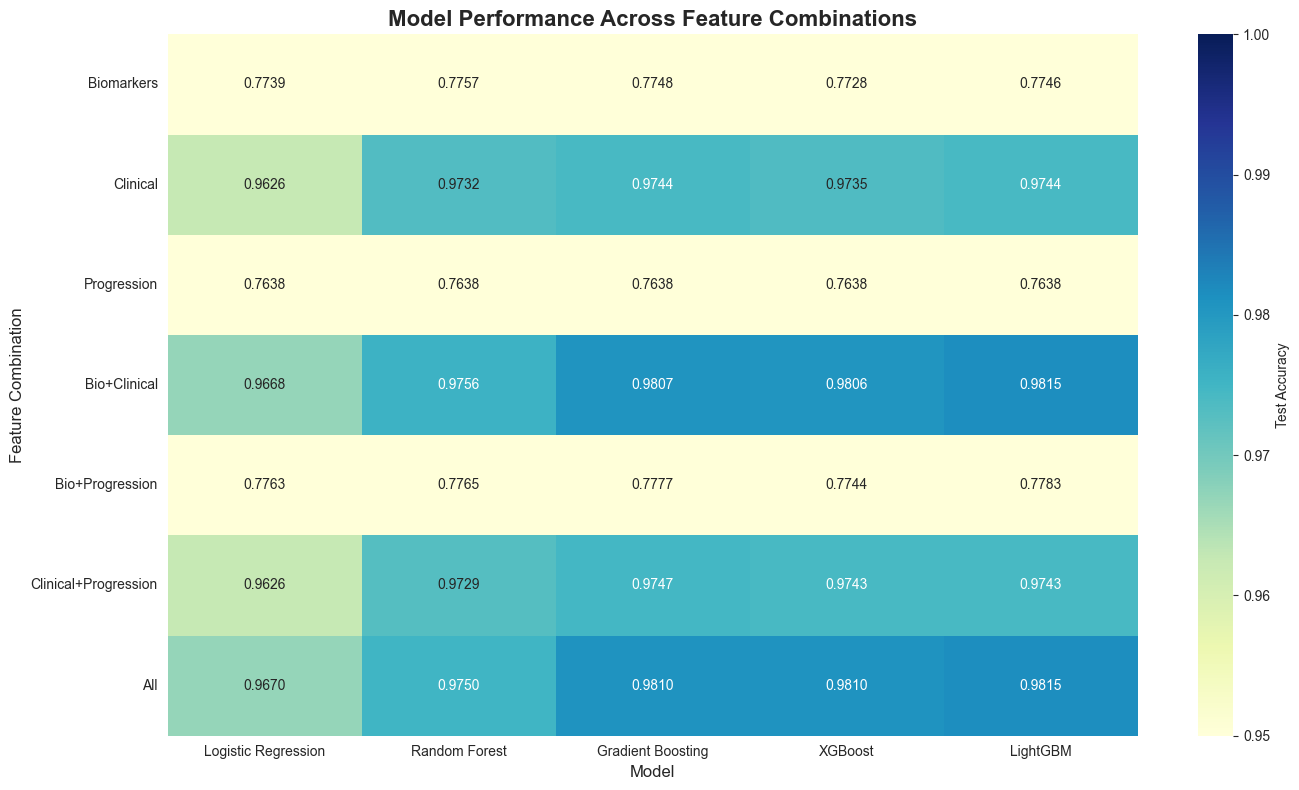

In [6]:
# Visualization 1: Heatmap of accuracies across models and combinations
heatmap_data = []
for combo_name in combinations:
    if combo_name not in all_results:
        continue
    row = [combo_name]
    for model_name in model_names:
        if model_name in all_results[combo_name]['cv_results']:
            acc = all_results[combo_name]['cv_results'][model_name]['test_accuracy'].mean()
            row.append(acc)
        else:
            row.append(np.nan)
    heatmap_data.append(row)

heatmap_df = pd.DataFrame(heatmap_data, columns=['Combination'] + model_names)
heatmap_df = heatmap_df.set_index('Combination')

plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_df, annot=True, fmt='.4f', cmap='YlGnBu', 
            vmin=0.95, vmax=1.0, cbar_kws={'label': 'Test Accuracy'})
plt.title('Model Performance Across Feature Combinations', fontsize=16, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Feature Combination', fontsize=12)
plt.tight_layout()
plt.show()

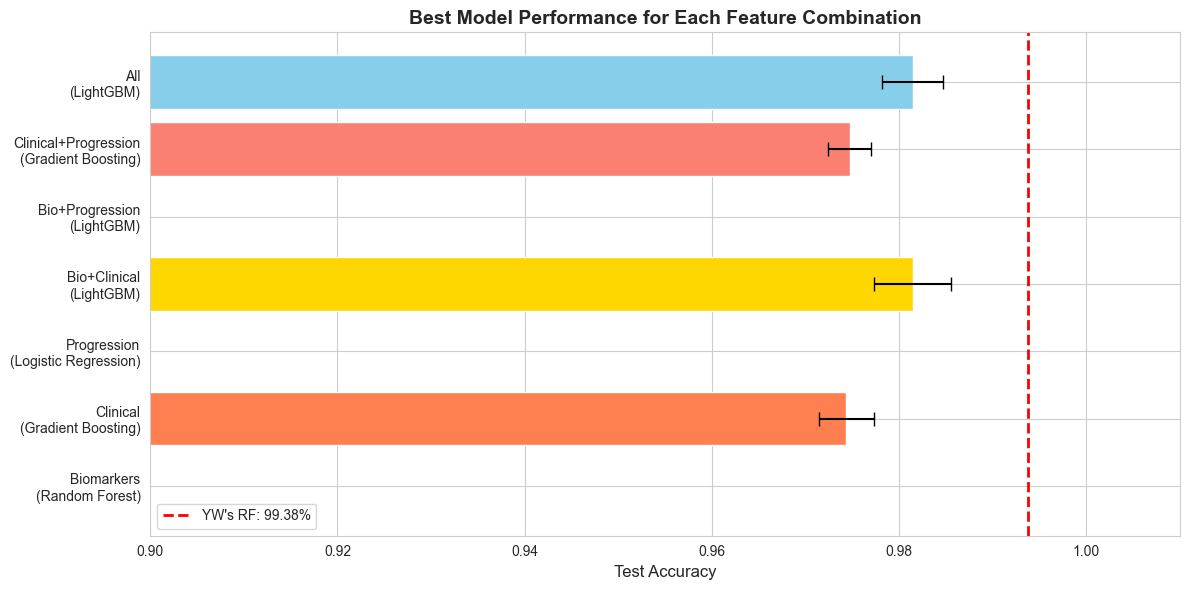

In [7]:
# Visualization 2: Bar plot comparing best model for each combination
best_results = []
for combo_name in combinations:
    if combo_name not in all_results:
        continue
    cv_results = all_results[combo_name]['cv_results']
    best_model = max(cv_results.items(), key=lambda x: x[1]['test_accuracy'].mean())
    best_results.append({
        'Combination': combo_name,
        'Model': best_model[0],
        'Accuracy': best_model[1]['test_accuracy'].mean(),
        'Std': best_model[1]['test_accuracy'].std()
    })

best_df = pd.DataFrame(best_results)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['steelblue', 'coral', 'lightgreen', 'gold', 'mediumpurple', 'salmon', 'skyblue']
bars = ax.barh(range(len(best_df)), best_df['Accuracy'], 
               xerr=best_df['Std'], color=colors[:len(best_df)], capsize=5)
ax.set_yticks(range(len(best_df)))
ax.set_yticklabels([f"{row['Combination']}\n({row['Model']})" for _, row in best_df.iterrows()])
ax.set_xlabel('Test Accuracy', fontsize=12)
ax.set_title('Best Model Performance for Each Feature Combination', fontsize=14, fontweight='bold')
ax.set_xlim([0.9, 1.01])
ax.axvline(x=0.9938, color='red', linestyle='--', linewidth=2, label="YW's RF: 99.38%")
ax.legend()
plt.tight_layout()
plt.show()

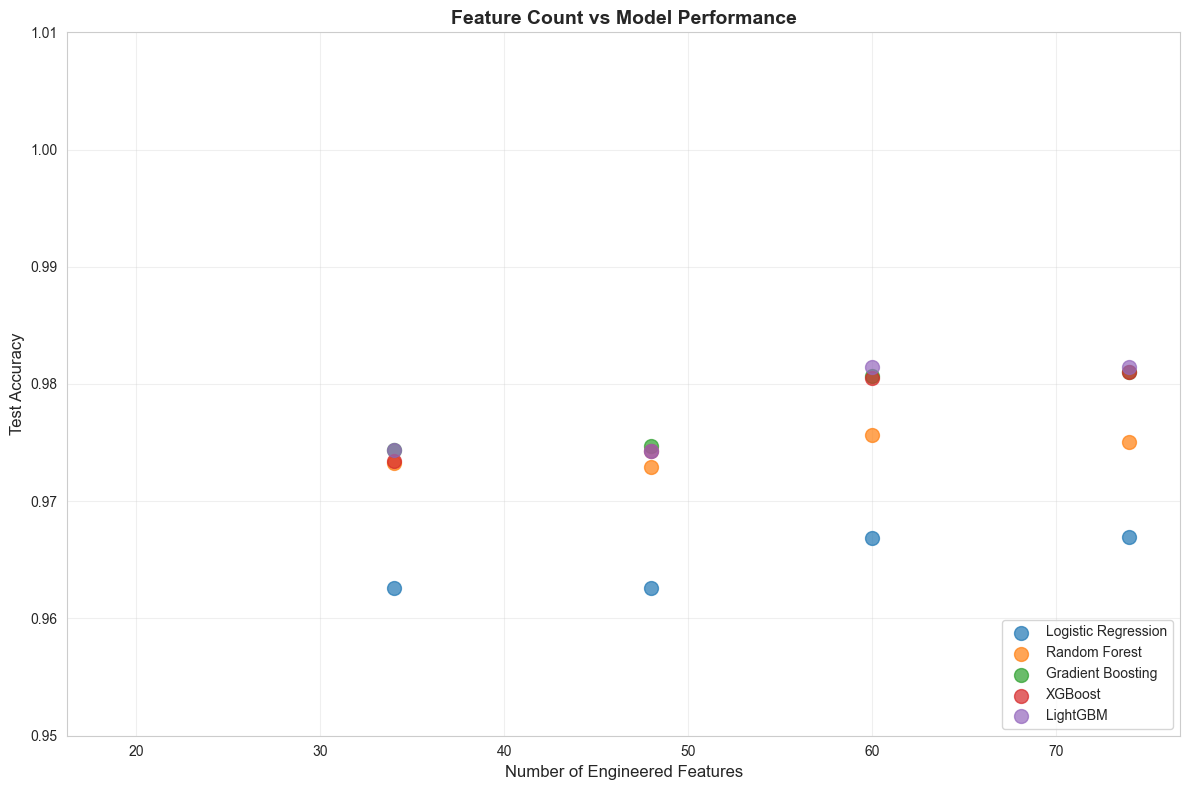

In [8]:
# Visualization 3: Feature count vs accuracy scatter plot
scatter_data = []
for combo_name in combinations:
    if combo_name not in all_results:
        continue
    feature_info = all_results[combo_name]['feature_info']
    cv_results = all_results[combo_name]['cv_results']
    
    for model_name in model_names:
        if model_name in cv_results:
            scatter_data.append({
                'Combination': combo_name,
                'Model': model_name,
                'N Features': feature_info['n_total_features'],
                'Accuracy': cv_results[model_name]['test_accuracy'].mean()
            })

scatter_df = pd.DataFrame(scatter_data)

fig, ax = plt.subplots(figsize=(12, 8))
for model_name in model_names:
    model_data = scatter_df[scatter_df['Model'] == model_name]
    ax.scatter(model_data['N Features'], model_data['Accuracy'], 
               label=model_name, s=100, alpha=0.7)

ax.set_xlabel('Number of Engineered Features', fontsize=12)
ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_title('Feature Count vs Model Performance', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_ylim([0.95, 1.01])
plt.tight_layout()
plt.show()

## 6. Key Findings and Summary

In [9]:
print("="*100)
print("KEY FINDINGS")
print("="*100)

print(f"\n1. Dataset Overview:")
print(f"   - Total samples: {len(y)}")
print(f"   - Classes: 3 (PD, SWEDD, HC)")
print(f"   - Feature combinations tested: {len(combinations)}")

print(f"\n2. Best Overall Performance:")
all_performances = []
for combo_name in combinations:
    if combo_name not in all_results:
        continue
    cv_results = all_results[combo_name]['cv_results']
    for model_name, metrics in cv_results.items():
        all_performances.append({
            'Combination': combo_name,
            'Model': model_name,
            'Accuracy': metrics['test_accuracy'].mean()
        })

best_overall = max(all_performances, key=lambda x: x['Accuracy'])
print(f"   - {best_overall['Model']} with {best_overall['Combination']}")
print(f"   - Accuracy: {best_overall['Accuracy']*100:.2f}%")

print(f"\n3. Performance by Feature Combination:")
for combo_name in combinations:
    if combo_name not in all_results:
        continue
    cv_results = all_results[combo_name]['cv_results']
    best_model = max(cv_results.items(), key=lambda x: x[1]['test_accuracy'].mean())
    print(f"   {combo_name}:")
    print(f"     Best: {best_model[0]} ({best_model[1]['test_accuracy'].mean()*100:.2f}%)")
    print(f"     Features: {all_results[combo_name]['feature_info']['n_original_features']} -> "
          f"{all_results[combo_name]['feature_info']['n_total_features']} (after engineering)")

print(f"\n4. Feature Engineering Impact:")
for combo_name in combinations:
    if combo_name not in all_results:
        continue
    feature_info = all_results[combo_name]['feature_info']
    transformed_count = sum(1 for info in feature_info['skewness_info'] if info.get('transformed', False))
    if transformed_count > 0:
        print(f"   {combo_name}: {transformed_count} features transformed due to skewness")

print(f"\n5. Comparison with YW's Results:")
print(f"   - YW Random Forest (all features): 99.38%")
print(f"   - This study best: {best_overall['Accuracy']*100:.2f}% ({best_overall['Model']}, {best_overall['Combination']})")
if best_overall['Accuracy'] >= 0.9938:
    print(f"   - Improvement: +{(best_overall['Accuracy'] - 0.9938)*100:.2f}%")
else:
    print(f"   - Difference: {(best_overall['Accuracy'] - 0.9938)*100:.2f}%")

print(f"\n6. Model Rankings (Average across all combinations):")
model_avg_acc = {}
for model_name in model_names:
    accs = [all_results[combo]['cv_results'][model_name]['test_accuracy'].mean() 
            for combo in combinations if combo in all_results and model_name in all_results[combo]['cv_results']]
    model_avg_acc[model_name] = np.mean(accs) if accs else 0

for model_name, avg_acc in sorted(model_avg_acc.items(), key=lambda x: x[1], reverse=True):
    print(f"   {model_name}: {avg_acc*100:.2f}%")

print("\n" + "="*100)

KEY FINDINGS

1. Dataset Overview:
   - Total samples: 8896
   - Classes: 3 (PD, SWEDD, HC)
   - Feature combinations tested: 7

2. Best Overall Performance:
   - LightGBM with Bio+Clinical
   - Accuracy: 98.15%

3. Performance by Feature Combination:
   Biomarkers:
     Best: Random Forest (77.57%)
     Features: 14 -> 31 (after engineering)
   Clinical:
     Best: Gradient Boosting (97.44%)
     Features: 16 -> 34 (after engineering)
   Progression:
     Best: Logistic Regression (76.38%)
     Features: 7 -> 19 (after engineering)
   Bio+Clinical:
     Best: LightGBM (98.15%)
     Features: 30 -> 60 (after engineering)
   Bio+Progression:
     Best: LightGBM (77.83%)
     Features: 21 -> 45 (after engineering)
   Clinical+Progression:
     Best: Gradient Boosting (97.47%)
     Features: 23 -> 48 (after engineering)
   All:
     Best: LightGBM (98.15%)
     Features: 37 -> 74 (after engineering)

4. Feature Engineering Impact:
   Biomarkers: 12 features transformed due to skewness
   